In [ ]:
import gdown

file_id = "14Sx-8YsgBgcicBM3xrmm965yVXh94omu"
output = "ir_fire_data.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=14Sx-8YsgBgcicBM3xrmm965yVXh94omu
From (redirected): https://drive.google.com/uc?id=14Sx-8YsgBgcicBM3xrmm965yVXh94omu&confirm=t&uuid=f3bc804c-a90a-447e-94ea-cae8b0969115
To: /content/ir_fire_data.zip
100%|██████████| 61.7M/61.7M [00:02<00:00, 21.9MB/s]


'ir_fire_data.zip'

In [ ]:
import torch, torchvision
print("Torch version:", torch.__version__)

!pip install -U 'git+https://github.com/facebookresearch/detectron2.git'



Torch version: 2.9.0+cu126
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-n66ma3t9
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-n66ma3t9
  Resolved https://github.com/facebookresearch/detectron2.git to commit fd27788985af0f4ca800bca563acdb700bb890e2
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 61.5 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=7085016 sha256=49c25ced0eddd2877264dc27531ceeef35f74fd177cf3eeed37dd836dff95e31
  Stored in directory: /tmp/pip-ephem-wheel-cache-vbb0_i13/wheel

In [ ]:
import os
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog, DatasetCatalog


COMBINED_ROOT = "/content/ir_fire_data/combined_coco"

IMAGES_DIR   = os.path.join(COMBINED_ROOT, "images")
TRAIN_JSON   = os.path.join(COMBINED_ROOT, "night_ir_train_balanced.json")
VAL_JSON     = os.path.join(COMBINED_ROOT, "night_ir_val_balanced.json")

print("Images dir:", IMAGES_DIR)
print("Train JSON:", TRAIN_JSON)
print("Val   JSON:", VAL_JSON)


register_coco_instances(
    "ir_fire_train",
    {},
    TRAIN_JSON,
    IMAGES_DIR,
)

register_coco_instances(
    "ir_fire_val",
    {},
    VAL_JSON,
    IMAGES_DIR,
)


MetadataCatalog.get("ir_fire_train").thing_classes = ["fire"]
MetadataCatalog.get("ir_fire_val").thing_classes   = ["fire"]

print("Registered datasets:", list(DatasetCatalog.list()))
print("Train classes:", MetadataCatalog.get("ir_fire_train").thing_classes)


Images dir: /content/ir_fire_data/combined_coco/images
Train JSON: /content/ir_fire_data/combined_coco/night_ir_train_balanced.json
Val   JSON: /content/ir_fire_data/combined_coco/night_ir_val_balanced.json
Registered datasets: ['coco_2014_train', 'coco_2014_val', 'coco_2014_minival', 'coco_2014_valminusminival', 'coco_2017_train', 'coco_2017_val', 'coco_2017_test', 'coco_2017_test-dev', 'coco_2017_val_100', 'keypoints_coco_2014_train', 'keypoints_coco_2014_val', 'keypoints_coco_2014_minival', 'keypoints_coco_2014_valminusminival', 'keypoints_coco_2017_train', 'keypoints_coco_2017_val', 'keypoints_coco_2017_val_100', 'coco_2017_train_panoptic_separated', 'coco_2017_train_panoptic_stuffonly', 'coco_2017_train_panoptic', 'coco_2017_val_panoptic_separated', 'coco_2017_val_panoptic_stuffonly', 'coco_2017_val_panoptic', 'coco_2017_val_100_panoptic_separated', 'coco_2017_val_100_panoptic_stuffonly', 'coco_2017_val_100_panoptic', 'lvis_v1_train', 'lvis_v1_val', 'lvis_v1_test_dev', 'lvis_v1_te

# **Training**

In [ ]:
import os
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.evaluation import COCOEvaluator
from detectron2.data import build_detection_test_loader
from detectron2.evaluation import inference_on_dataset

# 1) Build config from a COCO Faster R-CNN template
cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
)

# 2) Point to our datasets (registered in Cell 2)
cfg.DATASETS.TRAIN = ("ir_fire_train",)
cfg.DATASETS.TEST  = ("ir_fire_val",)

cfg.DATALOADER.NUM_WORKERS = 2   # OK for Colab

# 3) Solver / training hyperparams
cfg.SOLVER.IMS_PER_BATCH = 4
cfg.SOLVER.BASE_LR = 2.5e-4

cfg.SOLVER.MAX_ITER = 8000

# add LR decay schedule
cfg.SOLVER.STEPS = (4000, 7000)
cfg.SOLVER.GAMMA = 0.1

cfg.SOLVER.CHECKPOINT_PERIOD = 1000  # save model every 1000 iters

# 4) ROI heads for 1 class ("fire")
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1

# 5) Load COCO-pretrained weights
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"
)

# 6) Where to save outputs (new folder so we keep old results)
cfg.OUTPUT_DIR = "/content/ir_fire_outputs_v2"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
print("Training output dir:", cfg.OUTPUT_DIR)

# 7) Evaluate during training every 1000 iters
cfg.TEST.EVAL_PERIOD = 1000

# 8) Create trainer and train
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

# 9) Evaluate on the validation set after training
evaluator  = COCOEvaluator("ir_fire_val", cfg, False, output_dir=cfg.OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, "ir_fire_val")

print("Running evaluation on validation set...")
metrics = inference_on_dataset(trainer.model, val_loader, evaluator)
print("Validation metrics:", metrics)


Training output dir: /content/ir_fire_outputs_v2
[12/20 18:01:26 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_fea

model_final_280758.pkl: 167MB [00:00, 187MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}


[12/20 18:01:27 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W1220 18:01:30.388000 420 torch/fx/_symbolic_trace.py:52] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[12/20 18:01:42 d2.utils.events]:  eta: 1:14:17  iter: 19  total_loss: 1.641  loss_cls: 0.6567  loss_box_reg: 0.7287  loss_rpn_cls: 0.1628  loss_rpn_loc: 0.03098    time: 0.5792  last_time: 0.4916  data_time: 0.0324  last_data_time: 0.0188   lr: 4.9953e-06  max_mem: 3231M
[12/20 18:01:59 d2.utils.events]:  eta: 1:18:15  iter: 39  total_loss: 1.443  loss_cls: 0.6198  loss_box_reg: 0.6635  loss_rpn_cls: 0.1467  loss_rpn_loc: 0.02151    time: 0.5859  last_time: 0.6229  data_time: 0.0249  last_data_time: 0.0219   lr: 9.9902e-06  max_mem: 3231M
[12/20 18:02:11 d2.utils.events]:  eta: 1:18:53  iter: 59  total_loss: 1.483  loss_cls: 0.5749  loss_box_reg: 0.7399  loss_rpn_cls: 0.1415  loss_rpn_loc: 0.03498    time: 0.5906  last_time: 0.6435  data_time: 0.0260  last_data_time: 0.0235   lr: 1.4985e-05  max_mem: 3231M
[12/20 18:02:23 d2.utils.events]:  eta: 1:19:05  iter: 79  total_loss: 1.415  loss_cls: 0.5297  loss_box_reg: 0.6888  loss_rpn_cls: 0.1475  loss_rpn_loc: 0.0334    time: 0.5917  las

## **Testing with 4 pictures**

In [ ]:
import os
import cv2
import torch
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer, ColorMode

IMAGES_DIR = "/content/ir_fire_data/combined_coco/images"

def build_cfg_for_inference(weights_path, score_thresh=0.5):
    """
    Create a Detectron2 cfg for a 1-class (fire) Faster R-CNN model
    and load the given weights.
    """
    cfg = get_cfg()
    cfg.merge_from_file(
        model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
    )

    # one class: "fire"
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = score_thresh

    cfg.MODEL.WEIGHTS = weights_path
    cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    return cfg


def run_inference_on_images(weights_path, image_paths, out_dir, score_thresh=0.5):
    """
    Run detection on a list of images with a given model and
    save visualizations to out_dir.
    """
    os.makedirs(out_dir, exist_ok=True)

    cfg = build_cfg_for_inference(weights_path, score_thresh)
    predictor = DefaultPredictor(cfg)

    print(f"\nUsing weights: {weights_path}")
    print(f"Saving visualizations to: {out_dir}\n")

    for img_path in image_paths:
        img = cv2.imread(img_path)
        if img is None:
            print(f"[WARN] Could not read image: {img_path}")
            continue

        outputs = predictor(img)

        v = Visualizer(
            img[:, :, ::-1],  # BGR to RGB
            scale=1.0,
            instance_mode=ColorMode.IMAGE
        )
        v = v.draw_instance_predictions(outputs["instances"].to("cpu"))
        vis_img = v.get_image()[:, :, ::-1]  # back to BGR

        base = os.path.basename(img_path)
        save_path = os.path.join(out_dir, f"pred_{base}")
        cv2.imwrite(save_path, vis_img)

        print(f"Processed: {img_path}")
        print(f"Saved   : {save_path}\n")


# ==== 1) CHOOSE 4 TEST IMAGES (edit these names as you like) ====
test_images = [
    os.path.join(IMAGES_DIR, "hanyang_tr_00010.jpg"),
    os.path.join(IMAGES_DIR, "hanyang_tr_00020.jpg"),
    os.path.join(IMAGES_DIR, "forest_tr_01561.jpg"),
    os.path.join(IMAGES_DIR, "forest_tr_01562.jpg"),
]


weights = "/content/ir_fire_outputs/model_final.pth"

# Output folders for visualizations
out = "/content/ir_fire_vis_v2"

run_inference_on_images(weights, test_images, out, score_thresh=0.5)



Using weights: /content/ir_fire_outputs/model_final1.pth
Saving visualizations to: /content/ir_fire_vis_v1

Processed: /content/ir_fire_data/combined_coco/images/hanyang_tr_00010.jpg
Saved   : /content/ir_fire_vis_v1/pred_hanyang_tr_00010.jpg

Processed: /content/ir_fire_data/combined_coco/images/hanyang_tr_00020.jpg
Saved   : /content/ir_fire_vis_v1/pred_hanyang_tr_00020.jpg

Processed: /content/ir_fire_data/combined_coco/images/forest_tr_01561.jpg
Saved   : /content/ir_fire_vis_v1/pred_forest_tr_01561.jpg

Processed: /content/ir_fire_data/combined_coco/images/forest_tr_01562.jpg
Saved   : /content/ir_fire_vis_v1/pred_forest_tr_01562.jpg


Using weights: /content/ir_fire_outputs_v2/model_final2.pth
Saving visualizations to: /content/ir_fire_vis_v2

Processed: /content/ir_fire_data/combined_coco/images/hanyang_tr_00010.jpg
Saved   : /content/ir_fire_vis_v2/pred_hanyang_tr_00010.jpg

Processed: /content/ir_fire_data/combined_coco/images/hanyang_tr_00020.jpg
Saved   : /content/ir_fire_v

## **IR Full pipeline**

In [ ]:
!pip install -q "git+https://github.com/facebookresearch/segment-anything-2.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
detectron2 0.6 requires iopath<0.1.10,>=0.1.7, but you have iopath 0.1.10 which is incompatible.


In [ ]:
import torch
from sam2.build_sam import build_sam2_hf
from sam2.sam2_image_predictor import SAM2ImagePredictor

SAM_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("SAM2 device:", SAM_DEVICE)

SAM2 device: cuda


In [ ]:
import os, glob, json, math, csv
import numpy as np
import cv2
import rasterio
from rasterio.transform import xy as transform_xy
from pyproj import Transformer
import matplotlib.pyplot as plt


# Folder that contains GeoTIFF frames (IRX_0529_ref_geo.TIFF, IRX_0530_ref_geo.TIFF, ...)
GEOTIFF_DIR = "/content/geo_thermal_tiff_celsius"  # change to your folder


D2_WEIGHTS = "/content/model_final2.pth"    # change if needed

OUT_DIR = "/content/ir_geo_results"
os.makedirs(OUT_DIR, exist_ok=True)

FRAME_DT_SECONDS = 1.0

SCORE_THRESH = 0.20
MIN_AREA_M2  = 10.0      # ignore fires smaller than this area in the CSV/plots
TEMPORAL_ALPHA = 0.3
TEMPORAL_MASK_THRESH = 0.4

print("GEOTIFF_DIR:", GEOTIFF_DIR)
print("D2_WEIGHTS :", D2_WEIGHTS)
print("OUT_DIR    :", OUT_DIR)



GEOTIFF_DIR: /content/geo_thermal_tiff_celsius
D2_WEIGHTS : /content/model_final2.pth
OUT_DIR    : /content/ir_geo_results


In [ ]:
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2 import model_zoo

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1           # fire
cfg.MODEL.WEIGHTS = D2_WEIGHTS
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = SCORE_THRESH
cfg.MODEL.DEVICE = "cuda"  # "cpu" if no GPU

predictor_d2 = DefaultPredictor(cfg)
print("Detectron2 predictor loaded")


✅ Detectron2 predictor loaded


In [ ]:
!pip install -q "sahi>=0.11.15"
print("SAHI installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.6 MB/s eta 0:00:00
✅ SAHI installed


In [ ]:
# ---- SAHI + Detectron2 integration ----
from sahi.models.detectron2 import Detectron2DetectionModel
from sahi.predict import get_sliced_prediction

# 1) Save our modified Detectron2 cfg (1-class fire model) to a YAML file
D2_CONFIG_PATH = "/content/ir_frcnn_1cls.yaml"
with open(D2_CONFIG_PATH, "w") as f:
    f.write(cfg.dump())

print("Saved Detectron2 config for SAHI at:", D2_CONFIG_PATH)

# 2) Build SAHI Detectron2 model using our config and weights
d2_sahi_model = Detectron2DetectionModel(
    model_path=D2_WEIGHTS,          # your trained wildfire weights
    config_path=D2_CONFIG_PATH,     # the YAML we just saved
    confidence_threshold=SCORE_THRESH,
    device=str(SAM_DEVICE),         # "cuda" or "cpu"
)

print("SAHI Detectron2DetectionModel ready")

Saved Detectron2 config for SAHI at: /content/ir_frcnn_1cls.yaml
/content/ir_frcnn_1cls.yaml not available in Model Zoo!
✅ SAHI Detectron2DetectionModel ready


In [ ]:
import torch
from sam2.build_sam import build_sam2_hf
from sam2.sam2_image_predictor import SAM2ImagePredictor

SAM_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sam2_model = build_sam2_hf("facebook/sam2-hiera-large", device=SAM_DEVICE)
sam2_model.eval()

sam2_predictor = SAM2ImagePredictor(sam2_model)
print("SAM2 Large loaded")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


sam2_hiera_large.pt:   0%|          | 0.00/898M [00:00<?, ?B/s]

✅ SAM2 Large loaded


###**Define Inference & Geospatial Utility Functions**

In [ ]:
def read_geotiff_as_rgb8(tiff_path):
    with rasterio.open(tiff_path) as src:
        arr = src.read()
        transform = src.transform
        crs = src.crs

    if arr.shape[0] == 1:
        x = arr[0].astype(np.float32)
        x = x - np.nanmin(x)
        denom = (np.nanmax(x) + 1e-6)
        x = (x / denom * 255.0).clip(0, 255).astype(np.uint8)

        # pseudo-color to imitate IR palette
        colored_bgr = cv2.applyColorMap(x, cv2.COLORMAP_JET)
        img = cv2.cvtColor(colored_bgr, cv2.COLOR_BGR2RGB)
    else:
        x = arr[:3].transpose(1, 2, 0).astype(np.float32)
        x = x - np.nanmin(x)
        x = (x / (np.nanmax(x) + 1e-6) * 255.0).clip(0, 255).astype(np.uint8)
        img = x

    return img, transform, crs

def detect_fire_boxes_full(img_rgb, score_thresh=SCORE_THRESH):
    """
    Original full-frame Detectron2 inference.
    Uses predictor_d2 on the whole image.
    """
    out = predictor_d2(img_rgb)
    inst = out["instances"].to("cpu")

    if len(inst) == 0:
        return np.empty((0, 4), dtype=np.float32), np.empty((0,), dtype=np.float32)

    scores = inst.scores.numpy()
    boxes = inst.pred_boxes.tensor.numpy()

    keep = scores >= score_thresh
    boxes = boxes[keep]
    scores = scores[keep]

    return boxes.astype(np.float32), scores.astype(np.float32)


def detect_fire_boxes_sahi(
    img_rgb,
    score_thresh=SCORE_THRESH,
    slice_h=512,
    slice_w=512,
    overlap_ratio=0.2,
):
    """
    SAHI + Detectron2 sliced prediction.
    Uses d2_sahi_model (SAHI wrapper around your Detectron2 weights).
    """
    result = get_sliced_prediction(
        image=img_rgb,
        detection_model=d2_sahi_model,
        slice_height=slice_h,
        slice_width=slice_w,
        overlap_height_ratio=overlap_ratio,
        overlap_width_ratio=overlap_ratio,
    )

    if len(result.object_prediction_list) == 0:
        return np.empty((0, 4), dtype=np.float32), np.empty((0,), dtype=np.float32)

    boxes = []
    scores = []

    for obj in result.object_prediction_list:
        bbox = obj.bbox
        x1, y1, x2, y2 = bbox.minx, bbox.miny, bbox.maxx, bbox.maxy
        score = float(obj.score.value)

        # extra safety filter
        if score < score_thresh:
            continue

        boxes.append([x1, y1, x2, y2])
        scores.append(score)

    if len(boxes) == 0:
        return np.empty((0, 4), dtype=np.float32), np.empty((0,), dtype=np.float32)

    return np.array(boxes, dtype=np.float32), np.array(scores, dtype=np.float32)



def sam2_mask_from_box(img_rgb, box_xyxy):
    sam2_predictor.set_image(img_rgb)
    box = np.array(box_xyxy, dtype=np.float32)

    with torch.inference_mode():
        masks, scores, logits = sam2_predictor.predict(
            box=box[None, :],
            multimask_output=False
        )

    return masks[0].astype(bool)


def pixel_area_m2(transform, crs, mask):
    px_w = transform.a
    px_h = transform.e
    px_area = abs(px_w * px_h)

    if crs and crs.is_projected:
        return float(mask.sum() * px_area), "projected(meters)"

    ys, xs = np.where(mask)
    if len(xs) == 0:
        return 0.0, "empty"

    cy = int(np.mean(ys))
    cx = int(np.mean(xs))
    lon, lat = transform_xy(transform, cy, cx)

    meters_per_deg_lat = 111_320.0
    meters_per_deg_lon = 111_320.0 * math.cos(math.radians(lat))

    px_w_m = abs(px_w) * meters_per_deg_lon
    px_h_m = abs(px_h) * meters_per_deg_lat
    return float(mask.sum() * px_w_m * px_h_m), "geographic(approx)"


def mask_centroid_latlon(transform, crs, mask):
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None

    cy = float(np.mean(ys))
    cx = float(np.mean(xs))

    x_map, y_map = transform_xy(transform, cy, cx)

    if crs is None:
        return None
    if crs.to_epsg() == 4326:
        return (y_map, x_map)  # (lat, lon)

    transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    lon, lat = transformer.transform(x_map, y_map)
    return (lat, lon)


def overlay_and_save(img_rgb, box, score, mask, out_path):
    img = img_rgb.copy()

    if box is not None:
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 255), 2)
        cv2.putText(
            img,
            f"fire {score:.2f}",
            (x1, max(0, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 255),
            2,
        )

    if mask is not None and mask.any():
        overlay = img.astype(np.float32)
        overlay[mask] = 0.6 * overlay[mask] + 0.4 * np.array([255, 0, 0], dtype=np.float32)
        img = overlay.astype(np.uint8)

    cv2.imwrite(out_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))


### **Run Full Fire Analysis Pipeline (Detection + Tracking + Metrics)**

In [ ]:
# --- Find GeoTIFFs (handle .tif, .tiff, .TIF, .TIFF) ---
tiff_paths = []
for ext in ("*.tif", "*.tiff", "*.TIF", "*.TIFF"):
    tiff_paths.extend(sorted(glob.glob(os.path.join(GEOTIFF_DIR, ext))))
tiff_paths = sorted(set(tiff_paths))  # remove duplicates if any

print("Found GeoTIFFs:", len(tiff_paths))
if len(tiff_paths) > 0:
    print("First few files:")
    for p in tiff_paths[:5]:
        print("  ", p)
else:
    print("No GeoTIFF files found in:", GEOTIFF_DIR)

csv_path = os.path.join(OUT_DIR, "ir_fire_geo_area_growth.csv")

records = []
prev_area = None
prev_mask_prob = None

if len(tiff_paths) == 0:
    print("Skipping processing because there are no GeoTIFFs.")
else:
    for i, tiff_path in enumerate(tiff_paths):
        name = os.path.basename(tiff_path)

        img_rgb, transform, crs = read_geotiff_as_rgb8(tiff_path)

        # --- 1) full-frame detection ---
        boxes_full, scores_full = detect_fire_boxes_full(
            img_rgb,
            score_thresh=SCORE_THRESH,
        )

        # --- 2) SAHI sliced detection ---
        boxes_sahi, scores_sahi = detect_fire_boxes_sahi(
            img_rgb,
            score_thresh=SCORE_THRESH,
            slice_h=512,
            slice_w=512,
            overlap_ratio=0.2,
        )

        # --- 3) combine both sets of boxes ---
        if len(boxes_full) == 0 and len(boxes_sahi) == 0:
            boxes = np.empty((0, 4), dtype=np.float32)
            scores = np.empty((0,), dtype=np.float32)
        elif len(boxes_full) == 0:
            boxes, scores = boxes_sahi, scores_sahi
        elif len(boxes_sahi) == 0:
            boxes, scores = boxes_full, scores_full
        else:
            boxes = np.concatenate([boxes_full, boxes_sahi], axis=0)
            scores = np.concatenate([scores_full, scores_sahi], axis=0)

                # ---------- A) instantaneous SAM2 mask from current frame ----------
        combined_mask_inst = np.zeros(img_rgb.shape[:2], dtype=bool)

        if len(boxes) == 0:
            # no detections this frame -> instantaneous mask stays all False
            gps = None
            vis_box = None
            vis_score = 0.0
        else:
            # segment each box with SAM2 and OR all masks together
            for b in boxes:
                m = sam2_mask_from_box(img_rgb, b)
                combined_mask_inst |= m

            # for visualization: use highest-score box
            best_i = int(np.argmax(scores))
            vis_box = boxes[best_i]
            vis_score = float(scores[best_i])

        # ---------- B) temporal tracking on the SAM2 mask ----------
        # convert bool -> float in {0,1} so we can do EMA
        inst_float = combined_mask_inst.astype(np.float32)

        if prev_mask_prob is None:
            # first frame: just take what we have
            mask_prob = inst_float
        else:
            # exponential moving average on masks
            mask_prob = (
                TEMPORAL_ALPHA * inst_float
                + (1.0 - TEMPORAL_ALPHA) * prev_mask_prob
            )

        # threshold probabilities to get the *temporal* fire mask
        temporal_mask = mask_prob >= TEMPORAL_MASK_THRESH

        # store for next frame
        prev_mask_prob = mask_prob

        # ---------- C) area & GPS from temporally tracked mask ----------
        area_m2, area_mode = pixel_area_m2(transform, crs, temporal_mask)
        gps = mask_centroid_latlon(transform, crs, temporal_mask)

        # ignore very tiny fires in metrics
        if area_m2 < MIN_AREA_M2:
            area_m2 = 0.0
            gps = None
            temporal_mask[:] = False  # also clear the mask if you like

        # growth from temporally smoothed area
        if prev_area is None:
            growth = 0.0
        else:
            growth = (area_m2 - prev_area) / FRAME_DT_SECONDS
        prev_area = area_m2


        # 5) save overlay image (runs for both cases: fire or no fire)
        out_img = os.path.join(OUT_DIR, f"{os.path.splitext(name)[0]}_overlay.png")
        overlay_and_save(
            img_rgb,
            vis_box,
            vis_score,
            temporal_mask if 'temporal_mask' in locals() else None,
            out_img
        )

        lat, lon = (gps[0], gps[1]) if gps else (None, None)

        records.append([
            i, name,
            vis_score,
            area_m2,
            growth,
            lat, lon,
            str(crs),
        ])

        if (i + 1) % 10 == 0:
            print("Processed", i + 1, "frames")

    # write CSV once, after the loop
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "frame_idx", "file", "fire_score",
            "area_m2", "growth_m2_per_s",
            "lat", "lon", "crs"
        ])
        writer.writerows(records)

    print("Saved CSV:", csv_path)
    print("Saved overlays in:", OUT_DIR)


Found GeoTIFFs: 296
First few files:
   /content/geo_thermal_tiff_celsius/IRX_0529_ref_geo.TIFF
   /content/geo_thermal_tiff_celsius/IRX_0530_ref_geo.TIFF
   /content/geo_thermal_tiff_celsius/IRX_0531_ref_geo.TIFF
   /content/geo_thermal_tiff_celsius/IRX_0532_ref_geo.TIFF
   /content/geo_thermal_tiff_celsius/IRX_0533_ref_geo.TIFF
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Processed 10 frames
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing predict

### **Area & Growth Charts**

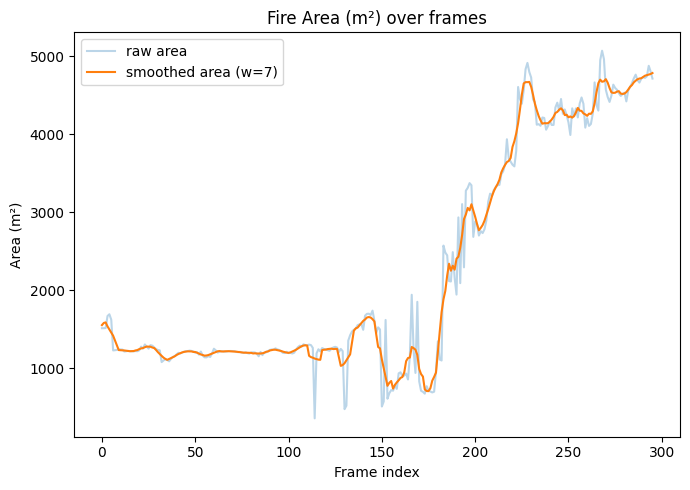

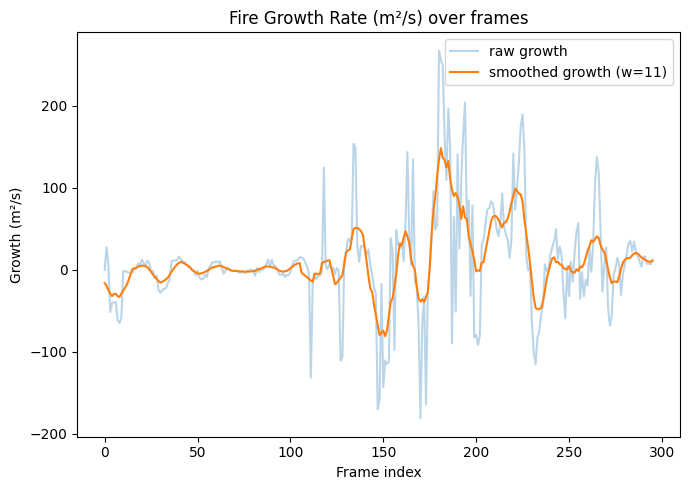

In [ ]:
# --- Plot only if we have data ---
if len(records) == 0:
    print("No records collected (no GeoTIFFs or no fire detections) – nothing to plot.")
else:
    # 1) raw areas & growth from the loop
    areas_raw   = [r[3] for r in records]   # area_m2

    # 2) simple moving-average smoothing for area
    def moving_average(x, window=5):
        """Centered moving average with window size (must be odd)."""
        if window < 1:
            return x
        half = window // 2
        out = []
        for i in range(len(x)):
            start = max(0, i - half)
            end   = min(len(x), i + half + 1)
            out.append(sum(x[start:end]) / (end - start))
        return out

    AREA_WINDOW = 7
    areas_smooth = moving_average(areas_raw, AREA_WINDOW)

    # 3) growth from smoothed area  -> this is the "raw" growth curve
    growth_raw = []
    for i, a in enumerate(areas_smooth):
        if i == 0:
            growth_raw.append(0.0)
        else:
            da = areas_smooth[i] - areas_smooth[i-1]
            growth_raw.append(da / FRAME_DT_SECONDS)

    # 4) smooth the growth curve as well
    GROWTH_WINDOW = 11   # can try 9, 11, 13 etc.
    growth_smooth = moving_average(growth_raw, GROWTH_WINDOW)

    # --------- PLOTS ---------

    # Fire area: raw vs smoothed
    plt.figure(figsize=(7,5))
    plt.plot(areas_raw,    label="raw area", alpha=0.3)
    plt.plot(areas_smooth, label=f"smoothed area (w={AREA_WINDOW})")
    plt.title("Fire Area (m²) over frames")
    plt.xlabel("Frame index")
    plt.ylabel("Area (m²)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Fire growth: raw vs smoothed
    plt.figure(figsize=(7,5))
    plt.plot(growth_raw,    label="raw growth", alpha=0.3)
    plt.plot(growth_smooth, label=f"smoothed growth (w={GROWTH_WINDOW})")
    plt.title("Fire Growth Rate (m²/s) over frames")
    plt.xlabel("Frame index")
    plt.ylabel("Growth (m²/s)")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
# Zip the folder, then download the zip
!zip -r ir_geo_results.zip ir_geo_results

from google.colab import files
files.download("ir_geo_results.zip")


updating: ir_geo_results/ (stored 0%)
updating: ir_geo_results/IRX_0756_ref_geo_overlay.png (deflated 4%)
updating: ir_geo_results/IRX_0617_ref_geo_overlay.png (deflated 10%)
updating: ir_geo_results/IRX_0818_ref_geo_overlay.png (deflated 8%)
updating: ir_geo_results/IRX_0670_ref_geo_overlay.png (deflated 6%)
updating: ir_geo_results/IRX_0573_ref_geo_overlay.png (deflated 11%)
updating: ir_geo_results/IRX_0718_ref_geo_overlay.png (deflated 5%)
updating: ir_geo_results/IRX_0742_ref_geo_overlay.png (deflated 4%)
updating: ir_geo_results/IRX_0535_ref_geo_overlay.png (deflated 8%)
updating: ir_geo_results/IRX_0698_ref_geo_overlay.png (deflated 6%)
updating: ir_geo_results/IRX_0684_ref_geo_overlay.png (deflated 6%)
updating: ir_geo_results/IRX_0574_ref_geo_overlay.png (deflated 11%)
updating: ir_geo_results/IRX_0791_ref_geo_overlay.png (deflated 6%)
updating: ir_geo_results/IRX_0538_ref_geo_overlay.png (deflated 8%)
updating: ir_geo_results/IRX_0556_ref_geo_overlay.png (deflated 11%)
updati

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>